# Loan Approval Prediction — ML Classification

**Goal:** Predict whether a loan application will be approved using applicant financial and demographic features.

Models compared:
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Gaussian Naive Bayes

**Note:** This notebook keeps the original learning approach but organizes the workflow more cleanly and avoids fitting preprocessing on the test set.

## 1. Import libraries
We use pandas/numpy for data handling, seaborn/matplotlib for visualization, and scikit-learn for preprocessing, models and evaluation.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)


## 2. Load and inspect the dataset
First, check the shape, data types and missing values before preprocessing.

In [2]:
data = pd.read_csv("loan_approval_data.csv")

print("Shape:", data.shape)
display(data.head())
data.info()

print("\nMissing values:")
display(data.isnull().sum())

Shape: (1000, 20)


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

## 3. Basic EDA
Look at the target distribution and a few important numerical relationships before training models.

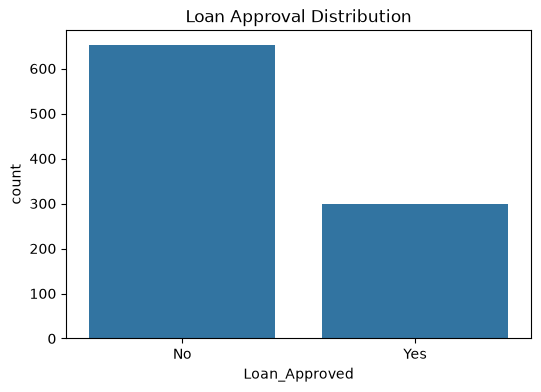

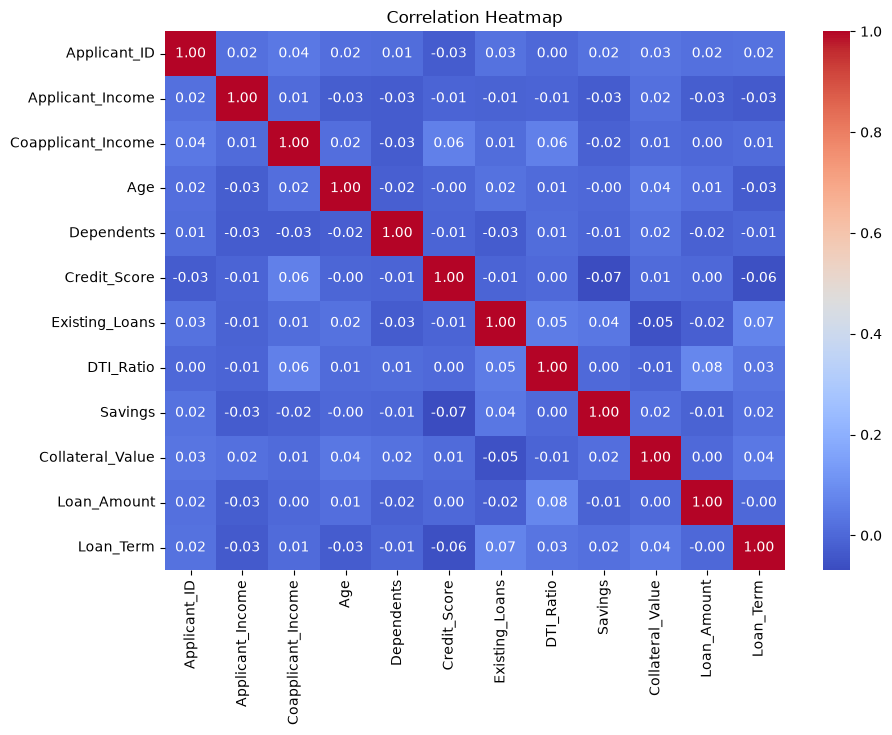

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="Loan_Approved")
plt.title("Loan Approval Distribution")
plt.show()

numeric_view = data.select_dtypes(include="number")
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_view.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 4. Separate features and target
`Applicant_ID` is an identifier, so it is removed rather than used as a predictive feature.

Important: the train/test split is done **before fitting imputers, encoders or scalers**. This prevents information from the test set leaking into training.

In [4]:
# Drop the identifier; it is not a meaningful predictive feature.
data = data.drop(columns=["Applicant_ID"], errors="ignore")

X = data.drop(columns=["Loan_Approved"])
y = data["Loan_Approved"].map({"No": 0, "Yes": 1})

# Remove rows with an unmapped target, if any.
valid_target = y.notna()
X, y = X.loc[valid_target], y.loc[valid_target].astype(int)

# Split before fitting imputers/scalers/encoders to avoid data leakage.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (760, 18)
Testing data: (190, 18)


## 5. Build the preprocessing pipeline
Numerical missing values are filled with the training-set mean. Categorical missing values use the most frequent category. Categorical features are one-hot encoded and numerical features are standardized.

Using a `ColumnTransformer` keeps the preprocessing reproducible and ensures that transformations are learned only from the training data.

In [5]:
# Infer feature types from the training set only.
numeric_features = X_train.select_dtypes(include="number").columns
categorical_features = X_train.select_dtypes(include=["object", "category", "string", "bool"]).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


## 6. Train and evaluate Logistic Regression

In [6]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_test)

print(classification_report(y_test, y_pred_logistic, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logistic))


              precision    recall  f1-score   support

           0       0.90      0.94      0.92       130
           1       0.85      0.78      0.82        60

    accuracy                           0.89       190
   macro avg       0.88      0.86      0.87       190
weighted avg       0.89      0.89      0.89       190

Confusion Matrix:
 [[122   8]
 [ 13  47]]


## 7. Train and evaluate KNN
KNN is sensitive to feature scale, which is why scaling is included in the preprocessing pipeline.

In [7]:
knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=21))
])

knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print(classification_report(y_test, y_pred_knn, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


              precision    recall  f1-score   support

           0       0.85      0.95      0.90       130
           1       0.85      0.65      0.74        60

    accuracy                           0.85       190
   macro avg       0.85      0.80      0.82       190
weighted avg       0.85      0.85      0.85       190

Confusion Matrix:
 [[123   7]
 [ 21  39]]


## 8. Train and evaluate Gaussian Naive Bayes
Gaussian Naive Bayes assumes that numerical features follow a Gaussian distribution.

In [8]:
# GaussianNB requires dense input; the shared preprocessor already outputs dense features.
nb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])

nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print(classification_report(y_test, y_pred_nb, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))


              precision    recall  f1-score   support

           0       0.88      0.95      0.91       130
           1       0.86      0.72      0.78        60

    accuracy                           0.87       190
   macro avg       0.87      0.83      0.85       190
weighted avg       0.87      0.87      0.87       190

Confusion Matrix:
 [[123   7]
 [ 17  43]]


## 9. Compare the models
Accuracy alone can be misleading, so compare precision, recall and F1-score as well.

In [9]:
predictions = {
    "Logistic Regression": y_pred_logistic,
    "KNN": y_pred_knn,
    "Gaussian Naive Bayes": y_pred_nb
}

results = []
for name, predictions_for_model in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions_for_model),
        "Precision": precision_score(y_test, predictions_for_model, zero_division=0),
        "Recall": recall_score(y_test, predictions_for_model, zero_division=0),
        "F1 Score": f1_score(y_test, predictions_for_model, zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.889474,0.854545,0.783333,0.817391
2,Gaussian Naive Bayes,0.873684,0.860000,0.716667,0.781818
1,KNN,0.852632,0.847826,0.650000,0.735849


## 10. What I learned
- Different classification algorithms can perform differently on the same dataset.
- Preprocessing is an important part of an ML workflow.
- KNN is affected by feature scaling.
- Precision, recall and F1-score provide more information than accuracy alone.
- Pipelines help keep preprocessing consistent between training and testing.

### Next improvements
- Try cross-validation instead of relying on a single train/test split.
- Tune hyperparameters for KNN and Logistic Regression.
- Experiment with additional classification algorithms.
- Investigate feature importance/model interpretability.
- Deploy the best model using an API after the ML workflow is stable.